In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

In [3]:
    # Dataset
    data = {
        "Income": [30, 35, 40, 70, 75, 80],
        "SpendingScore": [25, 30, 35, 80, 85, 90],
        "Segment": ["Regular", "Regular", "Regular",
                    "Premium", "Premium", "Premium"]
    }

In [4]:
df = pd.DataFrame(data)

In [5]:
df

,Income,SpendingScore,Segment
0,30,25,Regular
1,35,30,Regular
2,40,35,Regular
3,70,80,Premium
4,75,85,Premium
5,80,90,Premium


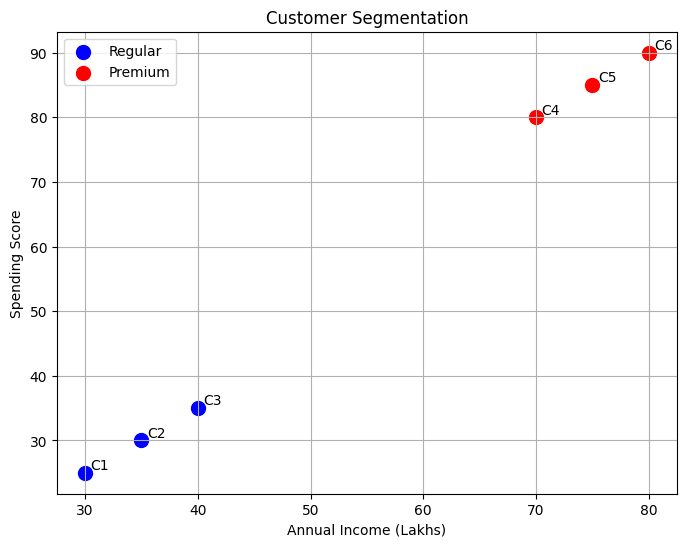

In [6]:
# Separate data by segment
regular = df[df["Segment"] == "Regular"]
premium = df[df["Segment"] == "Premium"]

# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    regular["Income"],
    regular["SpendingScore"],
    color="blue",
    s=100,
    label="Regular"
)

plt.scatter(
    premium["Income"],
    premium["SpendingScore"],
    color="red",
    s=100,
    label="Premium"
)

# Add customer labels
for i in range(len(df)):
    plt.text(
        df["Income"][i] + 0.5,
        df["SpendingScore"][i] + 0.5,
        f"C{i+1}"
    )

plt.title("Customer Segmentation")
plt.xlabel("Annual Income (Lakhs)")
plt.ylabel("Spending Score")
plt.legend()
plt.grid(True)

plt.show()

In [7]:
# Features and Target
X = df[["Income", "SpendingScore"]]
y = df["Segment"]

In [8]:
# Create KNN Model
model = KNeighborsClassifier(n_neighbors=3,weights='uniform')

In [9]:
# Train Model
model.fit(X, y)

KNeighborsClassifier(n_neighbors=3)

In [10]:
# Predict New Customer
y_pred = model.predict(X)

In [11]:
y_pred

array(['Regular', 'Regular', 'Regular', 'Premium', 'Premium', 'Premium'],
      dtype=object)

In [12]:
new_customer = [[30,25]]

prediction = model.predict(new_customer)

c:\Users\Amritanshu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [13]:
prediction

array(['Regular'], dtype=object)

In [14]:
for k in range(1,6):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X,y)

    print("K =",k,
          "Accuracy =",knn.score(X,y))

K = 1 Accuracy = 1.0
K = 2 Accuracy = 1.0
K = 3 Accuracy = 1.0
K = 4 Accuracy = 1.0
K = 5 Accuracy = 1.0


In [15]:
distance, index = model.kneighbors(new_customer)

print("Distances:", distance)
print("Indices:", index)

Distances: [[ 0.          7.07106781 14.14213562]]
Indices: [[0 1 2]]


c:\Users\Amritanshu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [16]:
print(model.classes_)

['Premium' 'Regular']


In [17]:
df["Prediction"] = model.predict(X)

df.to_csv("KNN_Result.csv",index=False)

print(df)

   Income  SpendingScore  Segment Prediction
0      30             25  Regular    Regular
1      35             30  Regular    Regular
2      40             35  Regular    Regular
3      70             80  Premium    Premium
4      75             85  Premium    Premium
5      80             90  Premium    Premium
